# Time Series

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import itertools
import warnings

## Data preprocessing

### Data collection

In [2]:
df = pd.read_csv('Data TH_Gold-Prices.csv')

In [3]:
df.describe()

,GPT(THB),GPW(USD),CPI,IR,POIL(USD),EXR
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,23481.250000,1492.038500,100.463750,1.370833,63.729917,33.233936
std,4802.441879,297.166848,3.565235,0.564145,20.007970,1.808449
min,18000.000000,1057.800000,96.650000,0.500000,19.330000,29.985700
25%,19700.000000,1247.010000,97.997500,0.937500,48.665000,31.859600
50%,20825.000000,1321.685000,99.255000,1.500000,59.475000,32.956250
75%,28175.000000,1789.585000,100.375000,1.750000,75.932500,34.822025
max,34000.000000,2065.150000,108.410000,2.500000,112.100000,37.920400


### Data cleansing

#### Clean datetime

In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

#### Set datetime index

In [5]:
df.index = df['Date'].values
df = df.drop(columns=['Date'])

#### Define target

In [6]:
target = 'GPT(THB)'

#### Check data type

In [7]:
df.dtypes

GPT(THB)       int64
GPW(USD)     float64
CPI          float64
IR           float64
POIL(USD)    float64
EXR          float64
dtype: object

#### Clean missing value

In [8]:
missing_values = df.isnull().sum()

In [9]:
print(df.isnull().sum())

GPT(THB)     0
GPW(USD)     0
CPI          0
IR           0
POIL(USD)    0
EXR          0
dtype: int64


#### Check missing timestamp

In [10]:
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')

In [11]:
full_range

DatetimeIndex(['2014-02-01', '2014-03-01', '2014-04-01', '2014-05-01',
               '2014-06-01', '2014-07-01', '2014-08-01', '2014-09-01',
               '2014-10-01', '2014-11-01',
               ...
               '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01',
               '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01',
               '2023-11-01', '2023-12-01'],
              dtype='datetime64[ns]', length=119, freq='MS')

In [12]:
missing_timestamps = full_range.difference(df.index)

In [13]:
missing_timestamps

DatetimeIndex(['2014-02-01', '2014-03-01', '2014-04-01', '2014-05-01',
               '2014-06-01', '2014-07-01', '2014-08-01', '2014-09-01',
               '2014-10-01', '2014-11-01',
               ...
               '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01',
               '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01',
               '2023-11-01', '2023-12-01'],
              dtype='datetime64[ns]', length=119, freq='MS')

### Time Series analysis

#### Observation

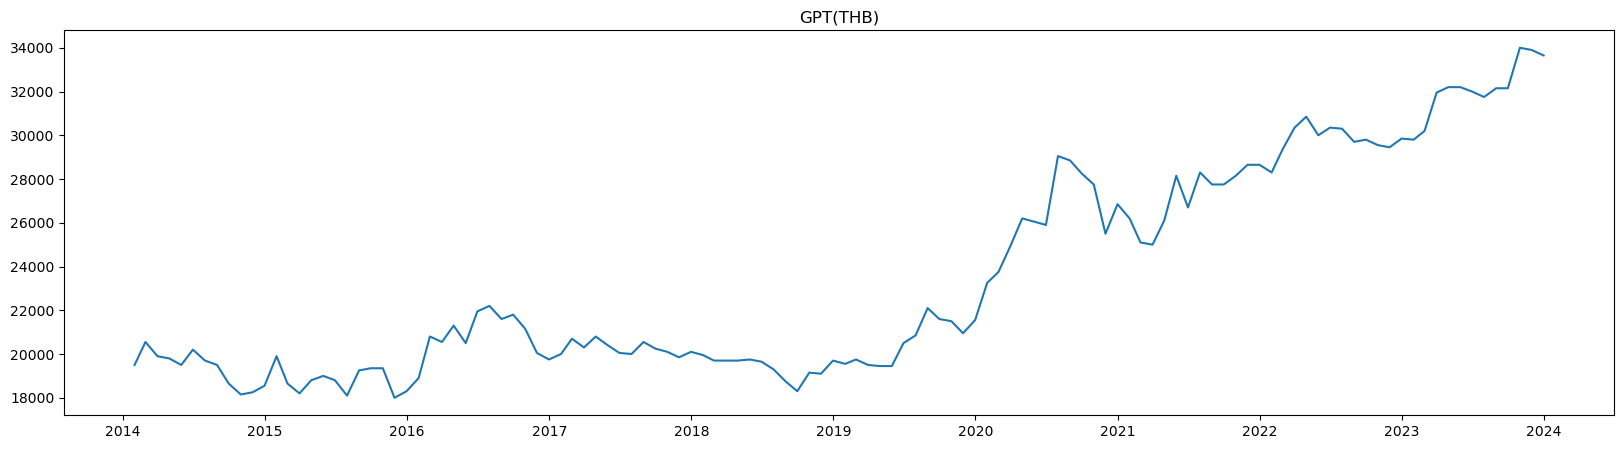

In [14]:
plt.figure(figsize=(20, 5))
plt.plot(df[target])
plt.title('GPT(THB)')
plt.show()

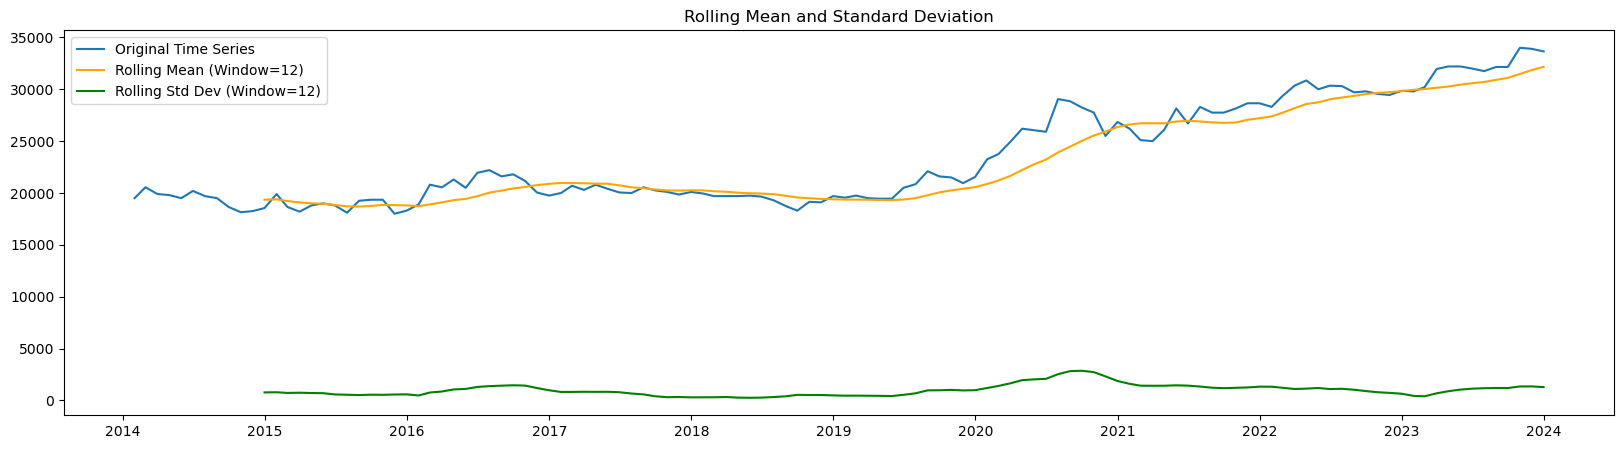

In [15]:
window_size = 12

rolling_mean = df[target].rolling(window=window_size).mean()
rolling_std = df[target].rolling(window=window_size).std()

plt.figure(figsize=(20, 5))
plt.plot(df[target], label='Original Time Series')
plt.plot(rolling_mean, label='Rolling Mean (Window=12)', color='orange')
plt.plot(rolling_std, label='Rolling Std Dev (Window=12)', color='green')
plt.title('Rolling Mean and Standard Deviation')
plt.legend()
plt.show()

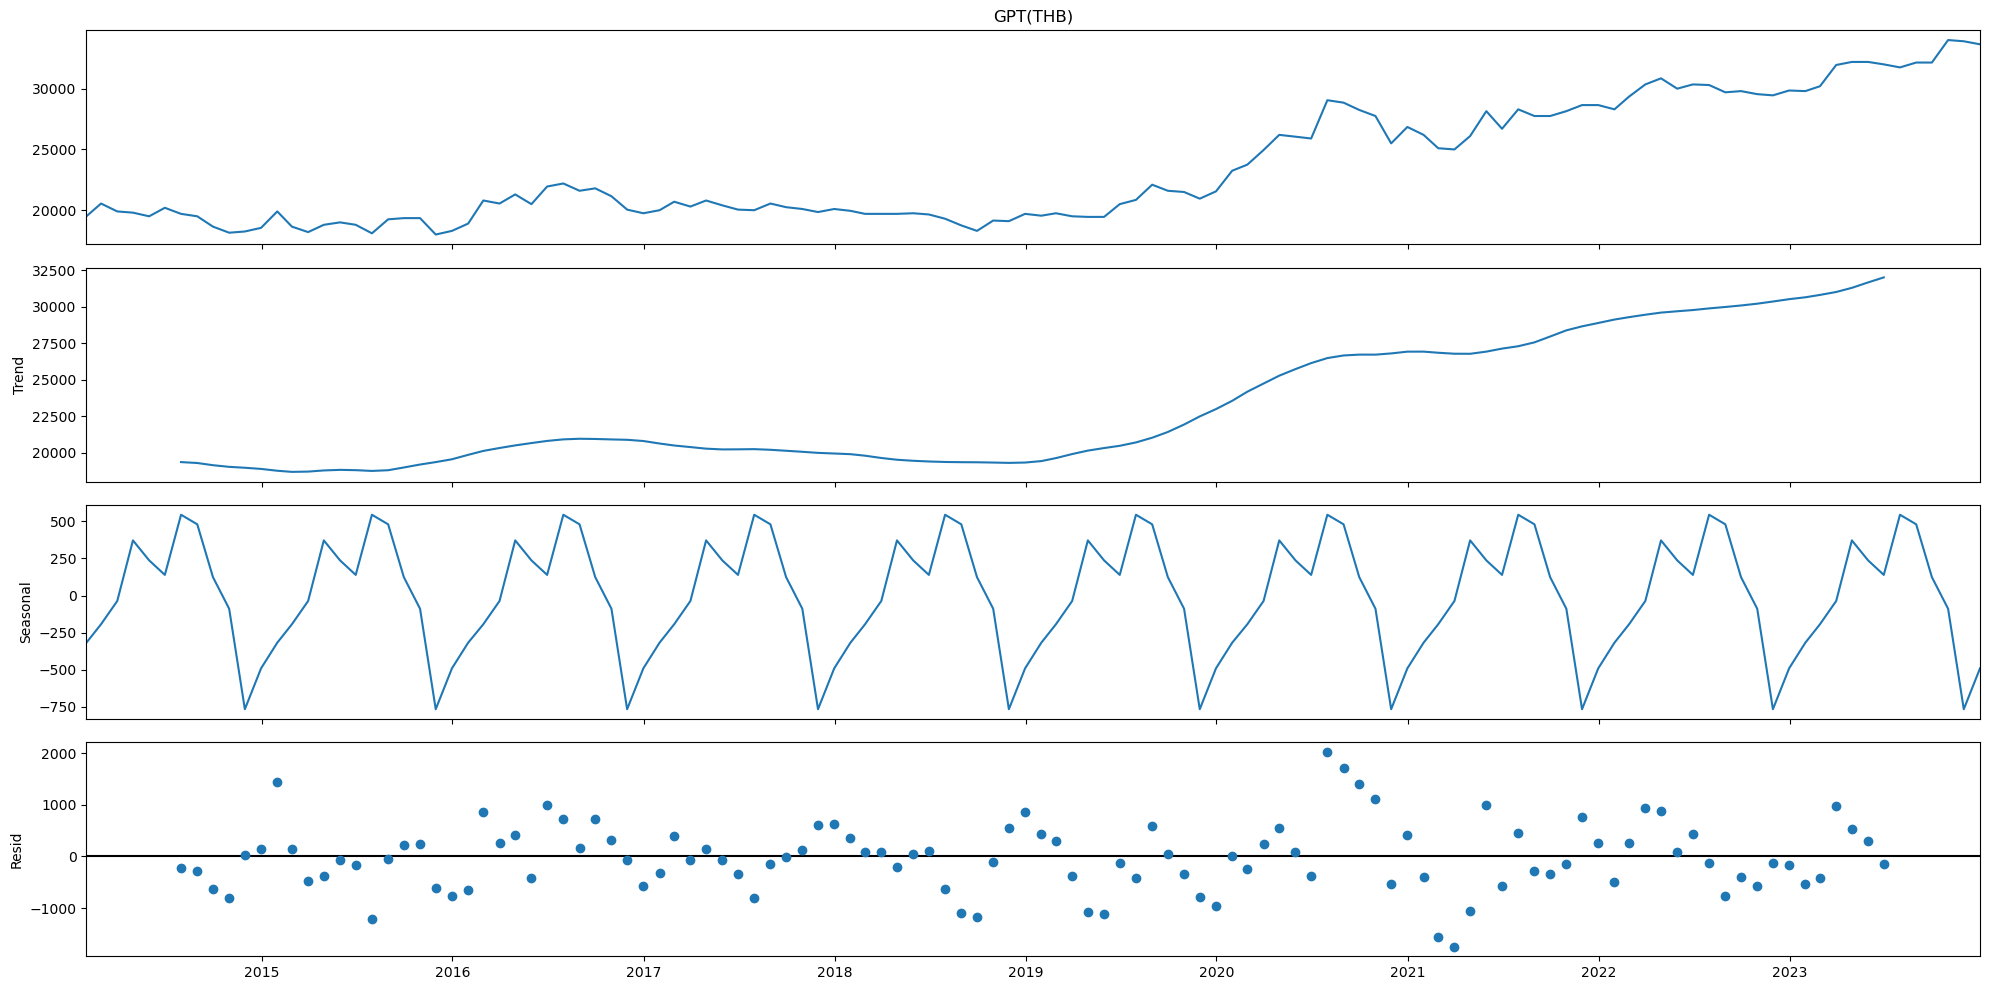

In [16]:
decomposition = seasonal_decompose(df[target], model='additive', period=12)

plt.rcParams.update({'figure.figsize': (20, 10)})
decomposition.plot()
plt.show()

In [17]:
adf_test_result = adfuller(df[target])

In [18]:
adf_test_result

(0.18077924227417438,
 0.9711627199977992,
 0,
 119,
 {'1%': -3.4865346059036564,
  '5%': -2.8861509858476264,
  '10%': -2.579896092790057},
 1719.4504396595923)

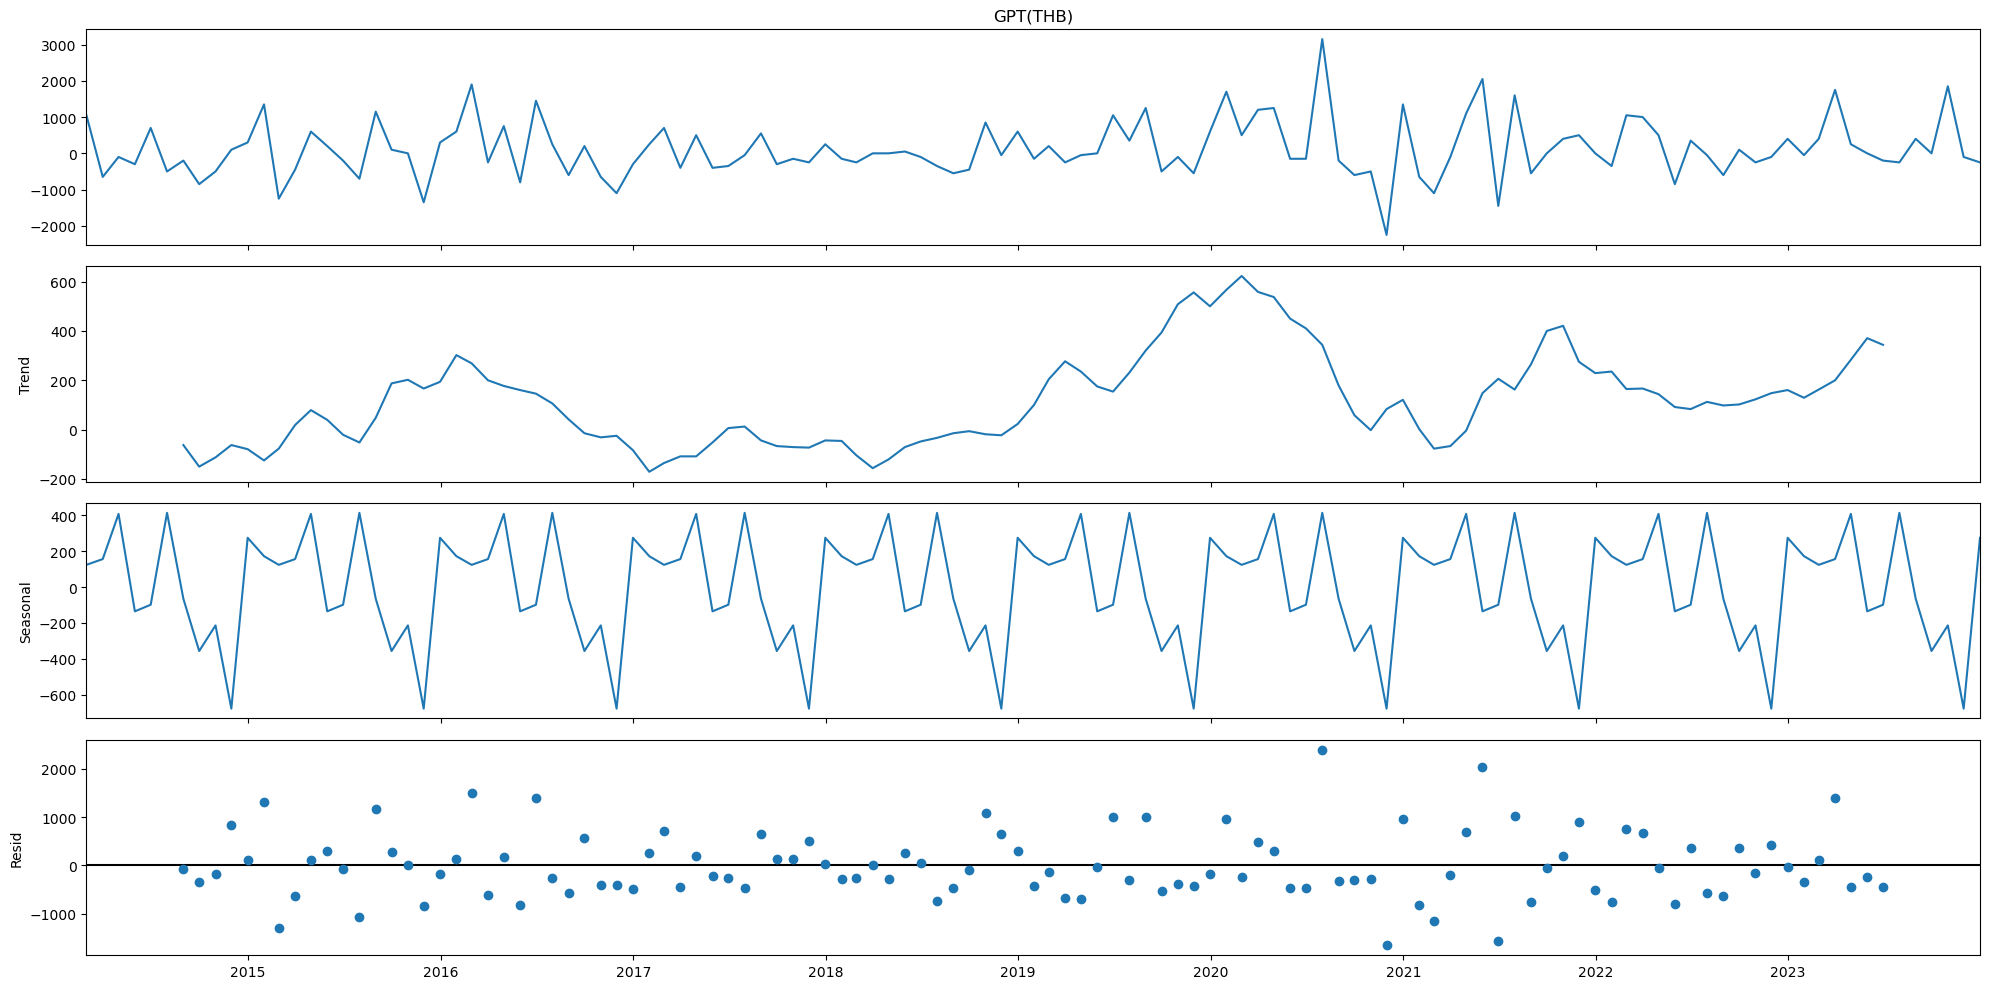

In [19]:
plt.rcParams.update({'figure.figsize': (20, 10)})

diff_series = df[target].diff().dropna()
decomposition = seasonal_decompose(diff_series, model='additive', period=12)
decomposition.plot()
plt.show()

In [20]:
adf_test_result = adfuller(diff_series)

In [21]:
adf_test_result

(-11.785202491426052,
 1.0126724453087843e-21,
 0,
 118,
 {'1%': -3.4870216863700767,
  '5%': -2.8863625166643136,
  '10%': -2.580009026141913},
 1702.9214950644573)

### Time series parameters

#### Autocorrelation

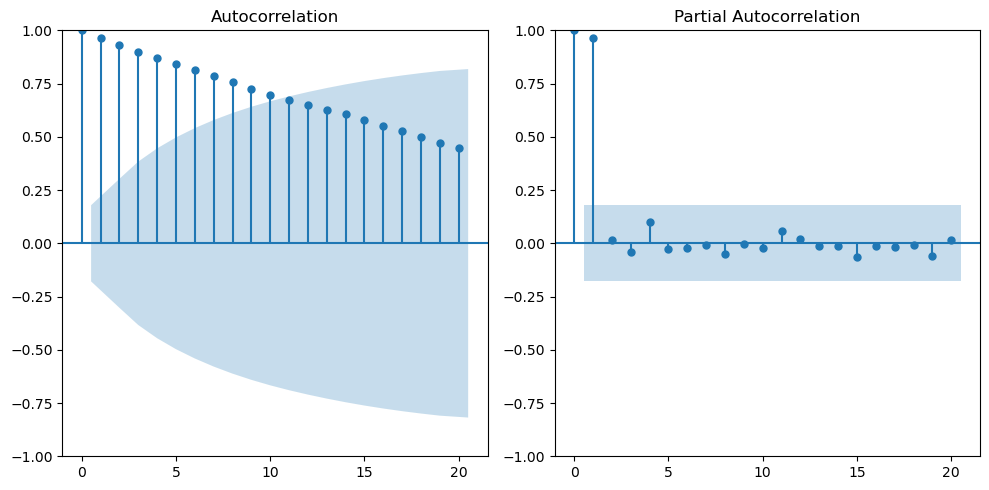

In [22]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plot_acf(df[target], lags=20, ax=plt.gca())
plt.subplot(122)
plot_pacf(df[target], lags=20, ax=plt.gca())
plt.tight_layout()
plt.show()

#### AIC

In [23]:
p = q = range(0, 4)
d = [1]
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_pdq = None
warnings.filterwarnings('ignore')

for param in pdq:
    try:
        model = ARIMA(df[target], order=param)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_pdq = param
    except:
        continue

In [24]:
best_pdq

(0, 1, 0)

### Feature selection

#### Granger test

In [25]:
raw_features = [x for x in df.columns if x != target]

In [26]:
max_lag = 5
granger_results = {}

for feature in raw_features:
    granger_result = grangercausalitytests(df[[target, feature]], maxlag=max_lag, verbose=False)
    granger_results[feature] = {lag: result[0]['ssr_ftest'] for lag, result in granger_result.items()}

In [27]:
for feature in raw_features:
    print(feature)
    print(pd.DataFrame(granger_results[feature], index=['F-statistic', 'p-values', 'degree-of-freedom', 'lag']))

GPW(USD)
                            1           2           3           4           5
F-statistic          0.220010    0.164965    0.153519    0.261190    0.324862
p-values             0.639912    0.848127    0.927227    0.902222    0.897004
degree-of-freedom  116.000000  113.000000  110.000000  107.000000  104.000000
lag                  1.000000    2.000000    3.000000    4.000000    5.000000
CPI
                            1           2           3           4           5
F-statistic          1.535924    3.260802    2.593607    3.167671    2.550807
p-values             0.217727    0.041996    0.056242    0.016729    0.032129
degree-of-freedom  116.000000  113.000000  110.000000  107.000000  104.000000
lag                  1.000000    2.000000    3.000000    4.000000    5.000000
IR
                            1           2           3           4           5
F-statistic          0.151393    0.162524    0.374856    0.439243    0.589974
p-values             0.697921    0.850194    0.7

#### Transform lag

In [28]:
df['CPI'] = df['CPI'].shift(4)
df = df.drop(columns=['GPW(USD)','IR','POIL(USD)','EXR'])
df = df.dropna()

In [29]:
X = df[['CPI']].dropna()

In [30]:
print("Shape of X", X.shape)

Shape of X (116, 1)


In [31]:
null_values = X.isnull().sum()

In [32]:
print(null_values)

CPI    0
dtype: int64


In [33]:
features = ['CPI']

### Split dataset

In [34]:
train_ratio = 0.7
train_size = int(train_ratio * len(df))
split_date = df.index[train_size]

In [35]:
train_df = df[df.index <= split_date]
test_df = df[df.index > split_date]

In [36]:
train_df.tail()

,GPT(THB),CPI
2020-10-31,27750,98.70
2020-11-30,25500,99.36
2020-12-31,26850,99.65
2021-01-31,26200,99.54
2021-02-28,25100,99.59


In [37]:
test_df.head()

,GPT(THB),CPI
2021-03-31,25000,99.55
2021-04-30,26100,99.70
2021-05-31,28150,99.79
2021-06-30,26700,98.88
2021-07-31,28300,99.11


### Feature engineering

In [38]:
y_train = train_df[target]
X_train = train_df[features]
y_test = test_df[target]
X_test = test_df[features]

#### Standardization

In [39]:
scaler = StandardScaler()

In [40]:
train_index = X_train.index
X_train_scale = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
X_train_scale.index = train_index

In [41]:
X_train_scale.head()

,CPI
2014-05-31,-0.972020
2014-06-30,-0.735884
2014-07-31,-0.539105
2014-08-31,-0.056994
2014-09-30,0.336565


In [42]:
test_index = X_test.index
X_test_scale = pd.DataFrame(scaler.transform(X_test), columns=features)
X_test_scale.index = test_index

## Model

In [43]:
model = ARIMA(y_train, exog=X_train, order=best_pdq)
model_fit = model.fit()

In [44]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               GPT(THB)   No. Observations:                   82
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -655.440
Date:                Fri, 03 Jul 2026   AIC                           1314.880
Time:                        09:06:05   BIC                           1319.668
Sample:                    05-31-2014   HQIC                          1316.801
                         - 02-28-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CPI         -306.8047    207.736     -1.477      0.140    -713.960     100.351
sigma2      6.255e+05   8.51e+04      7.351      0.000    4.59e+05    7.92e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.70   Jarque-Bera (JB):                13.00
Prob(Q):                              0.40   Prob(JB):                         0.00
Heteroskedasticity (H):               1.64   Skew:                             0.65
Prob(H) (two-sided):                  0.20   Kurtosis:                         4.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Evaluate

### Long step

In [45]:
y_pred = model_fit.forecast(len(y_test), exog=X_test)

In [46]:
mean_squared_error(y_pred, y_test)

49236132.375933625

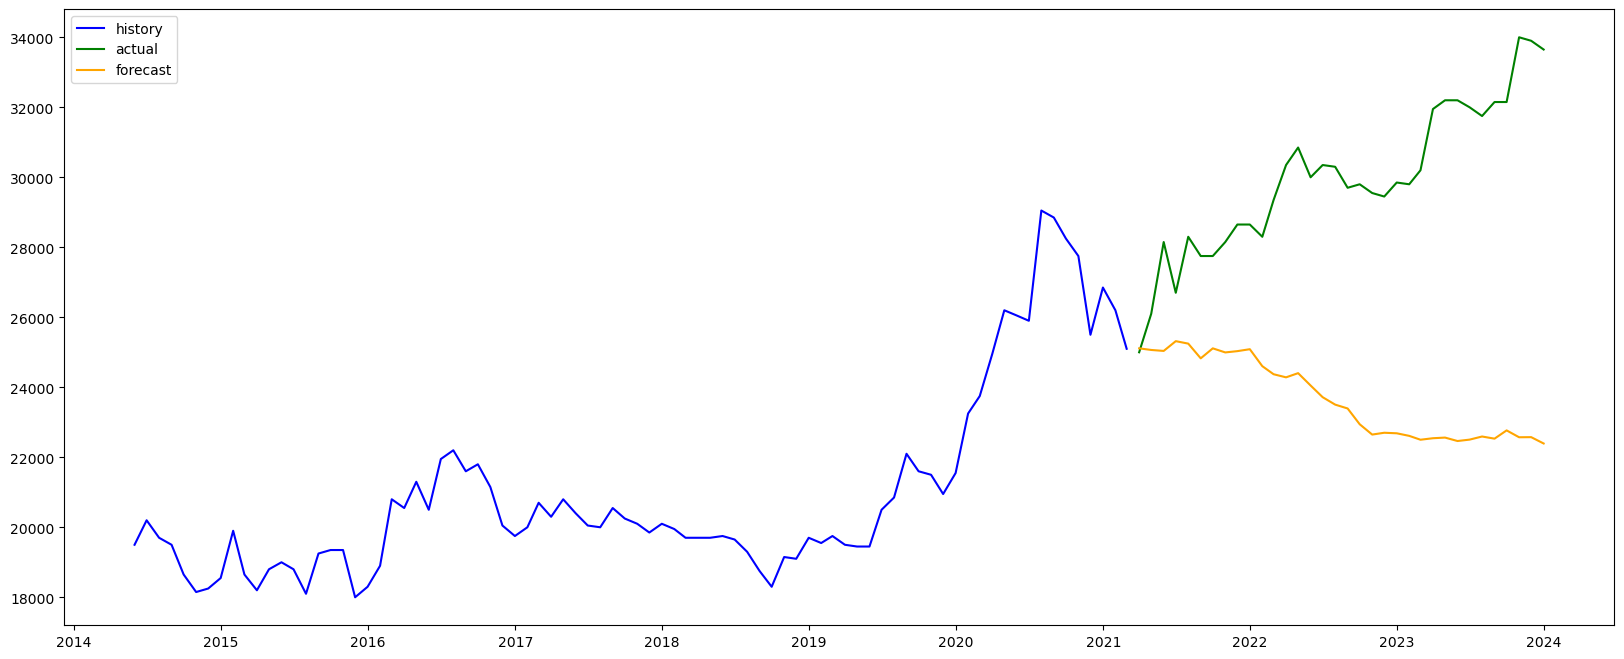

In [47]:
plt.figure(figsize=(20, 8))
plt.plot(y_train.index, y_train, c='blue', label='history')
plt.plot(y_test.index, y_test, c='green', label='actual')
plt.plot(y_test.index, y_pred, c='orange', label='forecast')
plt.legend()
plt.show()